# ASSIGNEMENT - 2

# COMP2200 - DATA SCIENCE

## Name: Jeebak Sabu

## Student ID: 48085847

## 1 Dataset Description & Problem Definition 

**Dataset:** https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn/data

**Rows:** Data of 10,000 customers  

**Goal:** Predict which customers will exit (churn) the bank.

| Column              | Meaning                                                            | Type    |
|---------------------|--------------------------------------------------------------------|---------|
| `RowNumber`         | Record index (drop)                                                | int     |
| `CustomerId`        | Unique customer identifier (drop)                                  | int     |
| `Surname`           | Customer last name (drop)                                          | string  |
| `CreditScore`       | Customer’s credit score                                            | int     |
| `Geography`         | Country of residence (France, Spain, Germany)                      | string  |
| `Gender`            | Male or Female                                                     | string  |
| `Age`               | Age in years                                                       | int     |
| `Tenure`            | Number of years as a bank client                                   | int     |
| `Balance`           | Account balance                                                    | float   |
| `NumOfProducts`     | Number of bank products held                                       | int     |
| `HasCrCard`         | 1 = has credit card, 0 = no credit card                            | int     |
| `IsActiveMember`    | 1 = active this month, 0 = inactive                                | int     |
| `EstimatedSalary`   | Annual salary estimate                                             | float   |
| `Complain`          | 1 = customer has complained, 0 = no complaint                      | int     |
| `SatisfactionScore` | Satisfaction score for complaint resolution (0 if no complaint)    | float   |
| `CardType`          | Type of credit card (Gold, Platinum, etc.)                         | string  |
| `PointsEarned`      | Loyalty points earned via card usage                               | int     |
| **`Exited`**        | **Target: 1 = churned (left the bank), 0 = stayed**                | **int** |


**Purposes of the Analysis**

1. Build a Churn‐Prediction Model
> Question: Which prediction model based on customer bank records will help in predicting who will leave the bank (Exit = 1).

- Rationale: Accurately anticipating churn allows banks to intervene with at-risk clients before they leave. Acquiring a new customer can cost 5 times more than retaining an existing one, so even little improvements in retention can result in significant cost savings.

2. Discover Key Churn Drivers
> Question: Identify what are the key churn drivers.

- Rationale: Understanding which indicators most strongly predict churn allows for customized campaigns rather than one-size-fits-all marketing, resulting in increased ROI.

3. Compare Modeling Approaches
> Question: How does a simple, interpretable baseline (logistic regression) compare to more complex algorithms (KNN, decision tree, random forest) in terms of classification accuracy, F-score, and ROC-AUC?

- Rationale: By comparing a transparent model to more powerful methodologies, the bank may balance the trade-off between interpretability and pure predictive capability.

4. Translate Insights into Action
> Based on our predictions and feature importance, what targeted retention tactics should the bank prioritize to reduce churn?

- Rationale: Linking analytic insights to tangible activities guarantees that this initiative has a meaningful commercial impact, transforming model outputs into particular, testable retention strategies.


## 2 Data Cleaning, Preprocessing & Exploration

## 2.1 Load the data

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load full dataset
bank_rec = pd.read_csv('Customer-Churn-Records.csv')

# displaying first 5 rows
bank_rec.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [17]:
# Checking the data and finding duplicates or missing values
bank_rec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [18]:
bank_rec.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DIAMOND,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,NaN,606.515100
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,NaN,225.924839
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,NaN,119.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,NaN,410.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,NaN,605.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,NaN,801.000000


In [19]:
bank_rec.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [20]:
bank_rec.duplicated().sum()

0

The Data seems to be clean and does not seem to contain values that can hinder my analysis

## 2.2 Cleaning & Preprocessing 🔧


In [28]:
# These columns only identify records and it doesn't add any value to my prediction I decided to drop them.
bank_rec = bank_rec.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# to make sure these clolumns that are to be used for predictions are type integers
for flag in ['Exited', 'HasCrCard', 'IsActiveMember', 'Complain']:
    bank_rec[flag] = bank_rec[flag].astype(int)

# I used pd.get_dummies to convert each text category into its own binary column, since machine-learning models require numeric inputs.
# For example, ‘Geography_Germany’ will be 1 if the customer is in Germany, else 0.
bank_rec = pd.get_dummies(
    bank_rec,
    columns=['Geography', 'Gender', 'Card Type'],
    drop_first=True
)

# Applying StandardScaler so that features with large numeric ranges don’t dominate features with smaller ranges (e.g., Tenure).
from sklearn.preprocessing import StandardScaler

num_feats = [
    'CreditScore','Age','Tenure','Balance',
    'NumOfProducts','EstimatedSalary','Satisfaction Score','Point Earned'
]
scaler = StandardScaler()

# Fit on the data and transform in one step, each column now has mean=0 and SD=1
bank_rec[num_feats] = scaler.fit_transform(bank_rec[num_feats])


# Here I am separating the input features (X) from the churn label (y), which is required for train/test splitting and model fitting.
X = bank_rec.drop(columns='Exited')
y = bank_rec['Exited']

# Confirming that the dimensions of X and y match expectations, and preview the first few rows of the feature matrix.
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
display(X.head())



Feature matrix shape: (10000, 17)
Target vector shape: (10000,)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,-0.721130,-0.630839,False,False,False,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,1,-0.009816,-0.666251,False,True,False,False,False,False
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,-0.009816,-1.015942,False,False,False,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,1.412812,-1.135457,False,False,False,True,False,False
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,1.412812,-0.803472,False,True,False,True,False,False


After preprocessing, the feature matrix **X** has 10,000 rows and 17 columns, including seven standardized continuous variables (e.g., CreditScore, Age, Balance, Tenure, etc., each with mean aprox 0 and SD aprox 1), three binary flags (HasCrCard, IsActiveMember, Complain), and seven one-hot indicators for Geography (Germany, Spain, France(if drop_first != True), Gender (Male, Female(if drop_first != True)), and CardType (GOLD, PLATINUM, SILVER).  The target vector **y** is a one-dimensional array of length 10,000 that contains each customer's 'Exited' label.  The absence of raw identifiers confirms that  RowNumber,CustomerId, Surname have been successfully discarded while the presence of solely numeric and binary columns demonstrates that we correctly encoded categoricals and scaled all numeric features, preparing the dataset for model training.

## 2.3 Exploratory Analysis

C:\Users\Jeebak\AppData\Local\Temp\ipykernel_3512\2131379130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=bank_rec, ax=axes[0], palette=['#4c72b0','#55a868'])
C:\Users\Jeebak\AppData\Local\Temp\ipykernel_3512\2131379130.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed','Churned'])


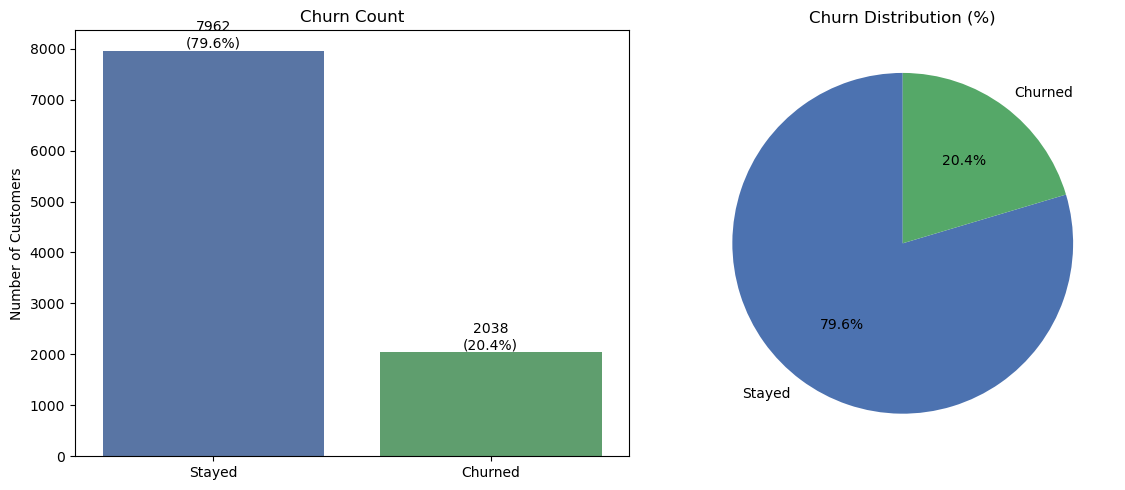

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# (a) Churn distribution: countplot and pie chart of relative churn %
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# 1) countplot with annotations
sns.countplot(x='Exited', data=bank_rec, ax=axes[0], palette=['#4c72b0','#55a868'])
axes[0].set_xticklabels(['Stayed','Churned'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
total = len(bank_rec)
for p in axes[0].patches:
    cnt = int(p.get_height())
    pct = cnt/total*100
    axes[0].annotate(f"{cnt}\n({pct:.1f}%)",
                     (p.get_x()+p.get_width()/2, cnt),
                     ha='center', va='bottom', fontsize=10)

counts = bank_rec['Exited'].value_counts()
axes[1].pie(counts,
            labels=['Stayed','Churned'],
            autopct='%1.1f%%',
            startangle=90,
            colors=['#4c72b0','#55a868'])
axes[1].set_title('Churn Distribution (%)')

plt.tight_layout()
plt.show()


This first part of the exploratory analysis examines the overall churn balance in the dataset. On the left, we utilize a Seaborn countplot to demonstrate that **7,962 customers (79.6%) stayed** and **2,038 (20.4%) churned**. On the right, a matching pie chart depicts the same percentages for easy reference. These plots show a moderate class imbalance about stayed vs. churned, which we should consider when training and evaluating our models.

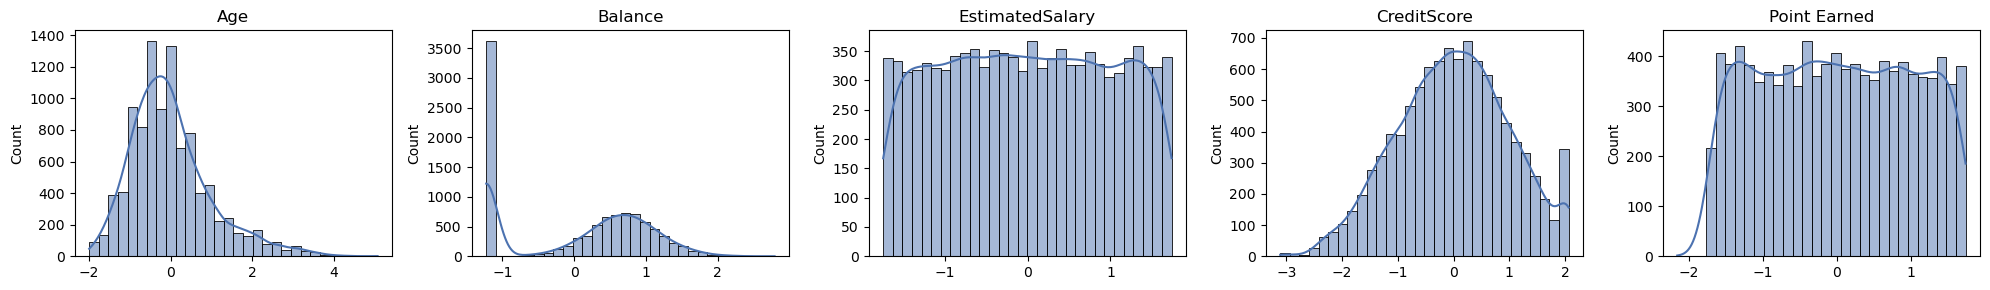

In [35]:
# (b) Numeric feature distributions
num_feats = ['Age', 'Balance', 'EstimatedSalary', 'CreditScore', 'Point Earned']
fig, axes = plt.subplots(1, len(num_feats), figsize=(20,3), sharey=False)

for ax, feat in zip(axes, num_feats):
    sns.histplot(bank_rec[feat], bins=30, kde=True, ax=ax, color='#4c72b0')
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


After standardizing our five key numeric variables, we see a range of distributional shapes that will help us plan our modeling method.  **Age** stays fairly bell-shaped but with a rightward tail, indicating that the majority of customers are in the intermediate age groups, with fewer being extremely young or very old.  **Balance** has an obvious bimodal distribution, with one peak at very low or zero balances and a larger hump among customers with large deposits.  When scaled, **EstimatedSalary** and **Points Earned** show a nearly equal distribution across their ranges, indicating a balanced mix of income levels and loyalty-point usage among our sample. Finally, **CreditScore** closely approximates a normal distribution centered at zero, which means that the majority of scores are close to the average and taper symmetrically toward the extremes.  These patterns support our decision to standardize and confirm that our future models must allow skewed, bimodal, and uniform feature forms. forms.
 forms.
 forms.
forms.

<Figure size 800x500 with 0 Axes>

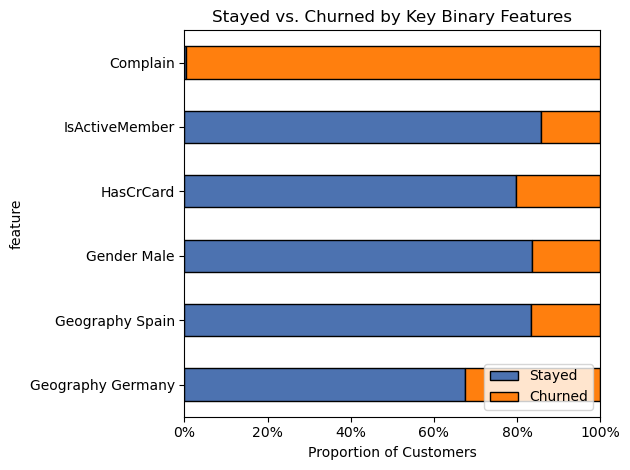

In [37]:
# (c) Churn rate by key discrete features
import pandas as pd
import matplotlib.pyplot as plt

# List of binary features to compare
disc_feats = [
    'Geography_Germany', 'Geography_Spain',
    'Gender_Male', 'HasCrCard',
    'IsActiveMember', 'Complain'
]

# Building a small DataFrame of stay vs. churn rates when feat == 1
rates = []
for feat in disc_feats:
    sub = bank_rec[bank_rec[feat] == 1]
    counts = sub['Exited'].value_counts(normalize=True)
    rates.append({
        'feature': feat.replace('_',' '),
        'Stayed': counts.get(0, 0),
        'Churned': counts.get(1, 0)
    })

rates_df = pd.DataFrame(rates).set_index('feature')

# Ploting stacked bar chart
plt.figure(figsize=(8,5))
rates_df.plot(
    kind='barh',
    stacked=True,
    color=['#4c72b0','#ff7f0e'],
    edgecolor='k'
)
plt.xlabel('Proportion of Customers')
plt.title('Stayed vs. Churned by Key Binary Features')
plt.legend(loc='lower right', title='')
plt.xlim(0,1)
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()


Comparing the proportion of consumers who stayed vs churned for each significant binary attribute, we can see a clear hierarchy of risk factors.  Customers who filed a **complaint** churned at nearly 100%, making complaint status by far the best predictor of leaving.  **Active members**, on the other hand, were extremely loyal, just roughly one-fifth of those identified as active churned, demonstrating the protective effect of continued participation.  **Possession of a credit card** and being male both resulted in significantly lower churn rates (approximately 20-25%) than their counterparts, indicating moderate retention benefits. Finally, **geographic disparities** were noticeable but not dramatic. Spanish consumers churned at about 25%, German customers at about 30%, and French customers, the inferred baseline whenever both 'Geography_Germany' and 'Geography_Spain' are zero, churned at around 20%.  Overall, complaint history dominates churn risk, with activity level, product use, and geography offering further information about who is most likely to depart.

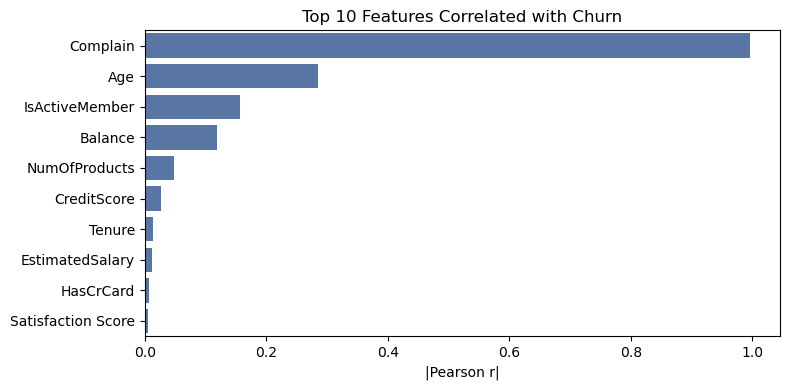

In [41]:
# The top 10 numeric correlations with churn 
num_cols = bank_rec.select_dtypes(include=[np.number]).columns
corr_vals = (
    bank_rec[num_cols]
      .corr()['Exited']
      .abs()
      .sort_values(ascending=False)
      .iloc[1:11]
)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=corr_vals.values, y=corr_vals.index, ax=ax, color='#4c72b0')
ax.set_title('Top 10 Features Correlated with Churn')
ax.set_xlabel('|Pearson r|')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The top 10 numeric predictors are ranked in order of their absolute Pearson correlation with churn.  **Customer complaints** have an almost perfect correlation (r aprox 1.0), indicating that those who have submitted a complaint are highly likely to depart. Younger customers are more likely to churn, followed by age (r aprox 0.25), active-member status (r aprox 0.15), and account balance (r aprox 0.12).  Other factors, such as quantity of products, credit score, tenure, expected salary, credit card ownership, and satisfaction score, show weak correlations (|r|<0.05), indicating a minor influence in predicting turnover.  Overall, complaint history dominates, with demographic and engagement data serving as secondary predictors.

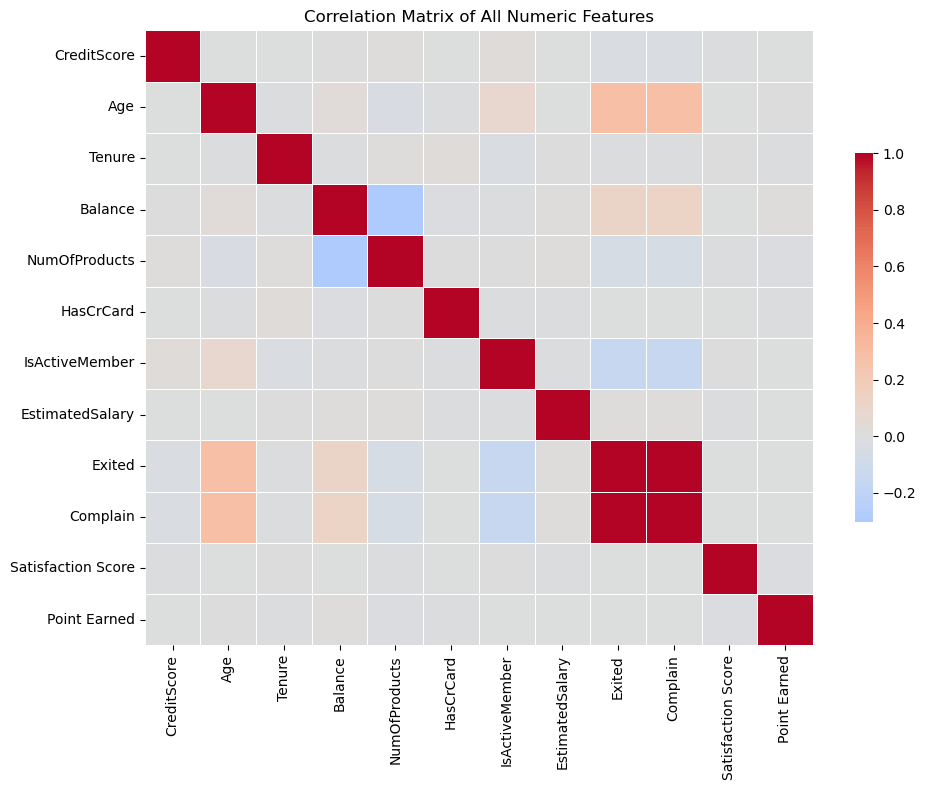

In [44]:
# Full correlation heatmap of all numeric features 
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(bank_rec[num_cols].corr(),
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={'shrink':0.6},
            ax=ax)
ax.set_title('Correlation Matrix of All Numeric Features')
plt.tight_layout()
plt.show()

As expected, each variable is completely correlated with itself.  Aside from that, the **strongest** off-diagonal positive connections exist between **'Exited' and 'Complain'**, indicating that consumers who have complained are considerably more likely to churn.  There is also a **small positive relationship** between **'Age' and churn**, as well as 'Balance' and churn , whereas 'IsActiveMember' is modestly negatively connected with turnover, showing that engaged consumers depart less frequently. Other pairs, such as 'Balance' vs. 'NumOfProducts', show a weak **negative correlation**, while the majority of the remaining cells are close to zero, indicating little linear link.

# 3. Modelling

In [48]:
# Creating train/test split
from sklearn.model_selection import train_test_split

# X and y has been defined earlier
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y    # preserves churn ratio in both splits
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)


X_train: (8000, 17)
X_test:  (2000, 17)
y_train: (8000,)
y_test:  (2000,)


## 3.1. Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=500, random_state=42)  
lr.fit(X_train, y_train)                                 

# Predictions
y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Train vs Test classification 
for split, y_true, y_pred in [
    ("Train", y_train, y_pred_train),
    ("Test",  y_test,  y_pred_test )
]:
    print(f"--- {split} Set ---")
    print(classification_report(y_true, y_pred, digits=3))

# Test ROC-AUC
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")


--- Train Set ---
              precision    recall  f1-score   support

           0      1.000     0.999     0.999      6370
           1      0.995     0.999     0.997      1630

    accuracy                          0.999      8000
   macro avg      0.997     0.999     0.998      8000
weighted avg      0.999     0.999     0.999      8000

--- Test Set ---
              precision    recall  f1-score   support

           0      0.999     0.999     0.999      1592
           1      0.998     0.995     0.996       408

    accuracy                          0.999      2000
   macro avg      0.998     0.997     0.998      2000
weighted avg      0.998     0.999     0.998      2000

Test ROC-AUC: 0.999


These near-perfect scores on both training and test sets indicate the Logistic Regression is extremely accurate and there is no obvious over or under fitting

Overall

> Accuracy (0.999): The model correctly classifies 99.9% of customers on the test set.

> ROC AUC (0.999): Near–perfect discrimination between churners and non-churners.

Class 0 (Stayed / Non-churners)

> Precision (0.999): Of all customers predicted to stay, 99.9% actually did.

> Recall (0.999): It captures 99.9% of all true non-churners.

> F1-Score (0.999): Harmonizes that near-perfect precision and recall.

> Support (1,592): There are 1,592 actual “Stayed” cases in the test set.

Class 1 (Churned / Churners)

> Precision (0.998): Of all customers predicted to churn, 99.8% actually did.

> Recall (0.995): It identifies 99.5% of all true churners.

> F1-Score (0.996): Excellent balance at 99.6%.

> Support (408): There are 408 actual “Churned” cases in the test set.

As a result, we can conclude that our model's average scores are approximately 99% successful and are balanced in recognizing both churners and non-churners.

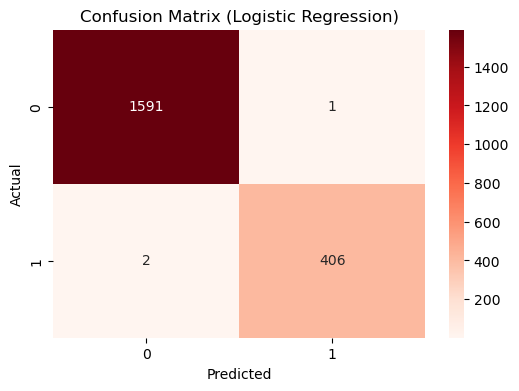

In [56]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt="d",cmap='Reds')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The above confusion matrix shows the true positives and true negatives for our model, as well as the false positives and false negatives, suggesting that the model's precision and recall are working pretty well.

## 3.2. K-Nearest Neighbors 

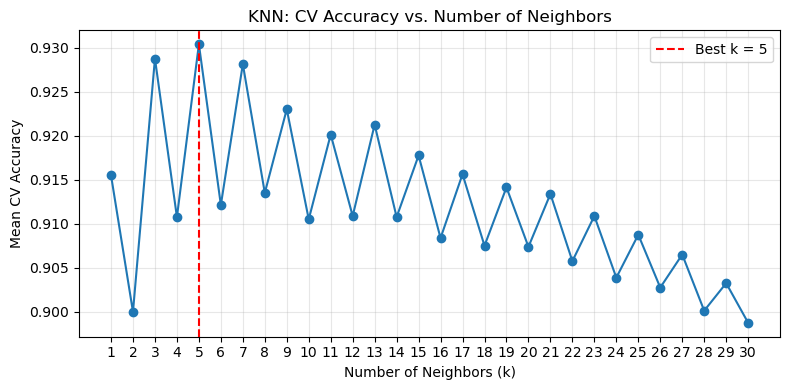

In [60]:
# Finding the right k value for performing KNN model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

# 1) Split into train & test (80/20), stratified on churn
X = bank_rec.drop(columns='Exited')
y = bank_rec['Exited']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2) GridSearch to find best k (1–30) via 5-fold CV on training set
param_grid = {'n_neighbors': list(range(1, 31))}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)
grid_knn.fit(X_train, y_train)

# 3) Ploting CV accuracy vs. k
plt.figure(figsize=(8,4))
plt.plot(
    param_grid['n_neighbors'],
    grid_knn.cv_results_['mean_test_score'],
    marker='o', linestyle='-'
)
best_k = grid_knn.best_params_['n_neighbors']
plt.axvline(best_k, color='red', linestyle='--', label=f"Best k = {best_k}")
plt.title('KNN: CV Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(param_grid['n_neighbors'])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [61]:
best_k = grid_knn.best_params_['n_neighbors']
print("Best k according to CV:", best_k)

Best k according to CV: 5


In [62]:
# Now building & fit a fresh KNN with that k value
knn_explicit = KNeighborsClassifier(n_neighbors=5)
knn_explicit.fit(X_train, y_train)

# Evaluate on train & test, just like your other models
y_pred_train = knn_explicit.predict(X_train)
y_pred_test  = knn_explicit.predict(X_test)
y_proba_knn = knn_explicit.predict_proba(X_test)[:, 1]

print(f"--- Train Set(k={best_k}) ---")
print(classification_report(y_train, y_pred_train, digits=3))
print(f"--- Test Set(k={best_k}) ---")
print(classification_report(y_test,  y_pred_test,  digits=3))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba_knn):.3f}")


--- Train Set(k=5) ---
              precision    recall  f1-score   support

           0      0.950     0.996     0.973      6370
           1      0.981     0.796     0.879      1630

    accuracy                          0.955      8000
   macro avg      0.966     0.896     0.926      8000
weighted avg      0.956     0.955     0.953      8000

--- Test Set(k=5) ---
              precision    recall  f1-score   support

           0      0.925     0.996     0.959      1592
           1      0.979     0.684     0.805       408

    accuracy                          0.932      2000
   macro avg      0.952     0.840     0.882      2000
weighted avg      0.936     0.932     0.928      2000

Test ROC AUC: 0.956


Overall

> Accuracy (0.932): The KNN model correctly classifies 93.2% of customers on the test set.

> ROC AUC (0.956): Strong discrimination between churners and non-churners, though not perfect.

Class 0 (Stayed / Non-churners)

> Precision (0.925): Of all customers predicted to stay, 92.5% actually did.

> Recall (0.996): It captures 99.6% of all true non-churners.

> F1-Score (0.959): Balances that high recall with precision.

> Support (1,592): There are 1,592 actual “Stayed” cases in the test set.

Class 1 (Churned / Churners)

> Precision (0.979): Of all customers predicted to churn, 97.9% actually did.

> Recall (0.684): It identifies only 68.4% of true churners, missing about 31.6%.

> F1-Score (0.805): Reflects the drop in sensitivity despite strong precision.

> Support (408): There are 408 actual “Churned” cases in the test set.


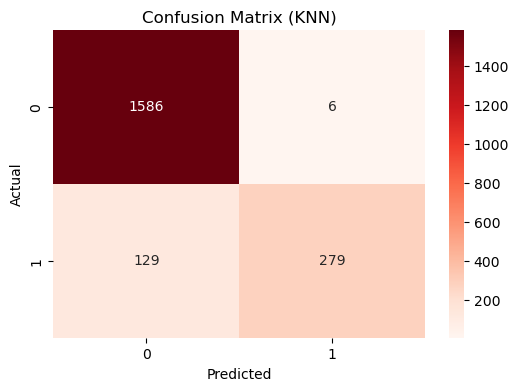

In [64]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title(f"Confusion Matrix (KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

From the above confusion matrix, KNN is good at ruling out non-churners but misses mises roughly 31.6% of actual churners.

## 3.3 Decision Tree 

In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1) Instantiate and fit a fresh Decision Tree
dt_explicit = DecisionTreeClassifier(random_state=42)
dt_explicit.fit(X_train, y_train)

# 2) Make predictions and get predicted probabilities
y_pred_train_dt = dt_explicit.predict(X_train)
y_proba_train_dt = dt_explicit.predict_proba(X_train)[:, 1]

y_pred_test_dt  = dt_explicit.predict(X_test)
y_proba_dt = dt_explicit.predict_proba(X_test)[:, 1]

# 3) Print Train vs Test reports
print("--- Train Set ---")
print(classification_report(y_train, y_pred_train_dt, digits=3))
print(f"Train ROC AUC: {roc_auc_score(y_train, y_proba_train_dt):.3f}\n")

print("--- Test Set ---")
print(classification_report(y_test, y_pred_test_dt, digits=3))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba_dt):.3f}")


--- Train Set ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      6370
           1      1.000     1.000     1.000      1630

    accuracy                          1.000      8000
   macro avg      1.000     1.000     1.000      8000
weighted avg      1.000     1.000     1.000      8000

Train ROC AUC: 1.000

--- Test Set ---
              precision    recall  f1-score   support

           0      0.997     0.999     0.998      1592
           1      0.995     0.990     0.993       408

    accuracy                          0.997      2000
   macro avg      0.996     0.994     0.995      2000
weighted avg      0.997     0.997     0.997      2000

Test ROC AUC: 0.994


Overall

> Accuracy (0.997): The decision tree correctly classifies 1 994 of 2 000 customers.

> ROC AUC (0.994): Excellent discriminative ability across all thresholds. Although there are a few misclassifications (2 false positives, 4 false negatives).

Class 0 (Stayed / Non-churners)

> Precision (0.997): Of all customers predicted to stay 1590 of 1594 were correct.

> Recall (0.999): It captures 1 590 of 1 592 which is approximately 99.9% of true non-churners.

> F1-Score (0.998): Harmonizes that near-perfect precision and recall.

> Support (1,592): There are 1 592 actual “Stayed” cases in the test set.

Class 1 (Churned / Churners)

> Precision (0.995): Of all customers predicted to churn, 404 actually did.

> Recall (0.990): It identifies 404 of 408 of true churners.

> F1-Score (0.993): Reflects the balance of very high precision with slightly lower recall.

> Support (408): There are 408 actual “Churned” cases in the test set.


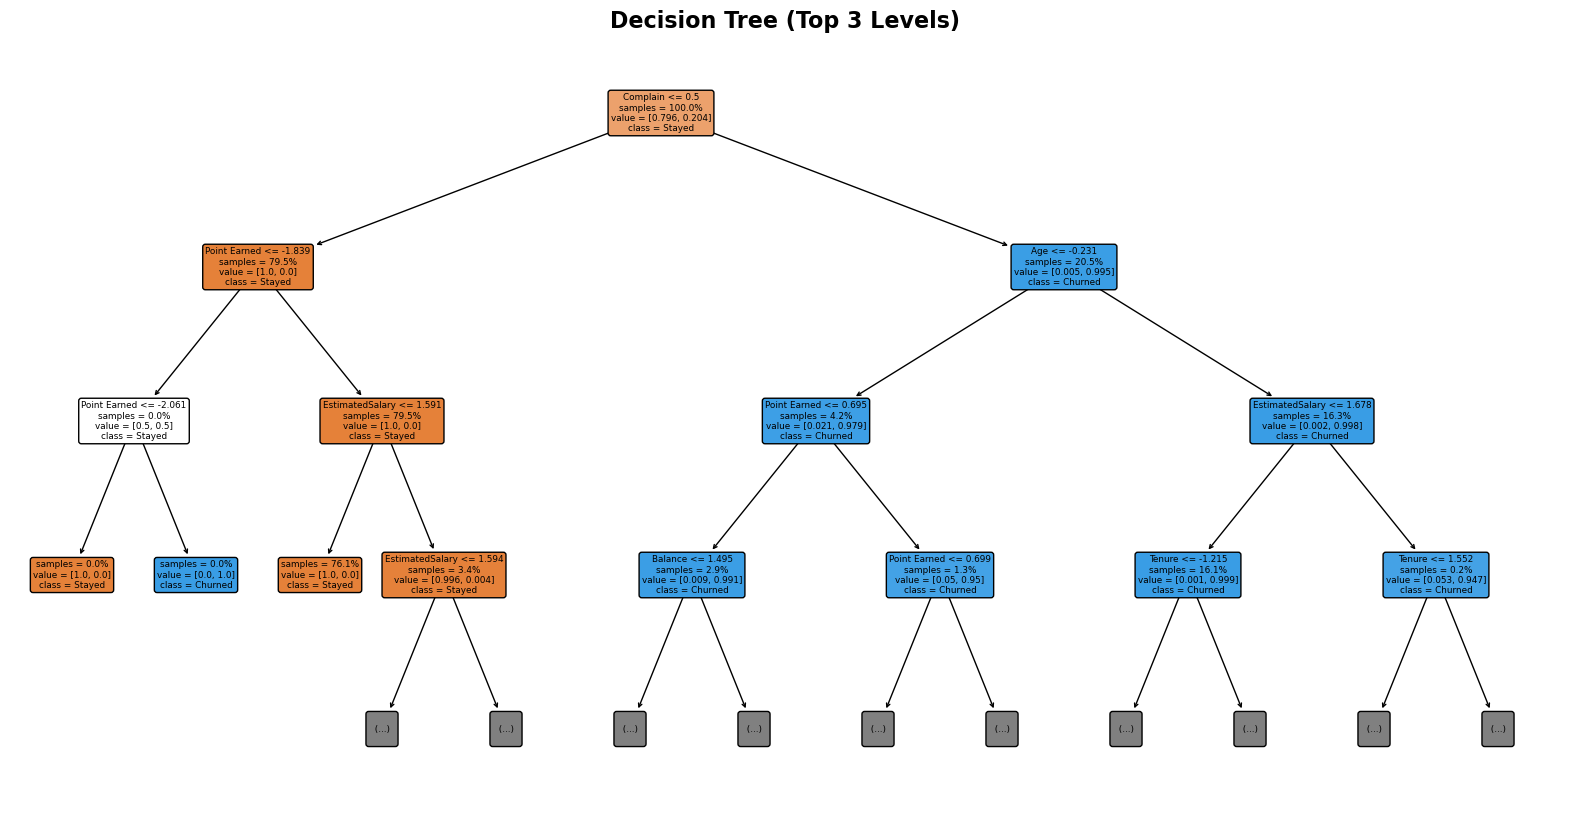

In [74]:
# Visualizing the Decision Tree Structure
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Ploting only the top 3 levels for readability
plt.figure(figsize=(20, 10))
tree.plot_tree(dt_explicit,feature_names=X_train.columns, class_names=['Stayed', 'Churned'], filled=True, rounded=True, impurity=False, proportion=True, max_depth=3)
plt.title("Decision Tree (Top 3 Levels)", fontsize=16, weight='bold')
plt.show()

The tree indicates that filing a complaint is the single most effective divider, non-churners nearly always stay, but complainers drive the majority of churn. Beyond that, loyalty points earned (for non-churners) and age (for churners) are the next most important factors. Low points indicate sticking, whereas younger complainers churn more. Finally, salary and tenure make minor adjustments in each branch, emphasizing the highest-risk areas (young, complaining, and low-engagement clients).

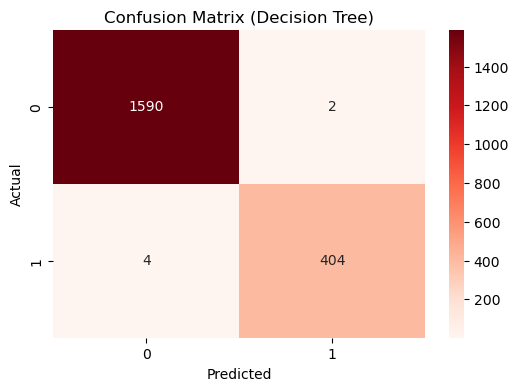

In [77]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_test_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix (Decision Tree)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 3.4. Random Forest 

In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# 1) representing and fitting on the training set
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2) Making predictions on both the splits
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Train vs Test classification reports
for split, y_true, y_pred in [
    ("Train", y_train, y_pred_train),
    ("Test",  y_test,  y_pred_test )
]:
    print(f"--- {split} Set ---")
    print(classification_report(y_true, y_pred, digits=3))

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")


--- Train Set ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      6370
           1      1.000     1.000     1.000      1630

    accuracy                          1.000      8000
   macro avg      1.000     1.000     1.000      8000
weighted avg      1.000     1.000     1.000      8000

--- Test Set ---
              precision    recall  f1-score   support

           0      0.999     0.999     0.999      1592
           1      0.998     0.995     0.996       408

    accuracy                          0.999      2000
   macro avg      0.998     0.997     0.998      2000
weighted avg      0.998     0.999     0.998      2000

Test ROC-AUC: 0.998


The Random Forest model fits the training data perfectly achieving 100% precision, recall, and F1-score for both non-churners and churners while also generalizing almost flawlessly to previously unseen data, with 99.9% overall accuracy on the testing set.  Specifically, it accurately identifies 99.9% of non-churners (precision and recall), 99.8% of churners (precision), and 99.5% of actual churners (recall), resulting in F1-scores more than 0.995 for both classes.  Its ROC-AUC of 0.998 demonstrates that the projected probabilities nearly precisely distinguish churners from non-churners.

Overall

>  Accuracy (0.999): The Random Forest correctly classifies 1,999 of 2 000 customers on the test set.

> ROC AUC (0.998): Near-perfect discrimination between churners and non-churners across all possible thresholds.

Class 0 (Stayed / Non-churners)

> Precision (0.999): Of all customers predicted to stay, 1,591 of 1,592 actually did.

> Recall (0.999): It captures 1,591 of 1,592  of true non-churners.

> F1-Score (0.999): Harmonizes that near-perfect precision and recall.

> Support (1,592): There are 1,592 actual “Stayed” cases in the test set.

Class 1 (Churned / Churners)

> Precision (0.998): Of all customers predicted to churn, 406 of 408 actually did.

> Recall (0.995): It identifies 406 of 408 of true churners.

> F1-Score (0.996): Reflects the balance of very high precision with slightly lower recall.

> Support (408): There are 408 actual “Churned” cases in the test set.

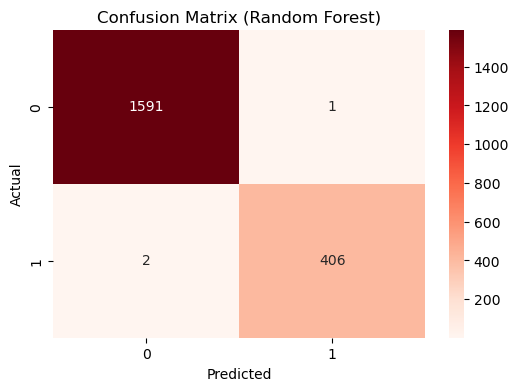

In [84]:
# Confusion Matrix for Random Forest on the test set
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Get test‐set predictions
y_pred_rf_test = rf.predict(X_test)

# 2) Compute the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf_test)

# 3) Plot it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The confusion matrix demonstrates that the Random Forest virtually never confuses one class for another.  Of the 1,592 true non-churners (class 0), it accurately predicted 1,591 and misclassified only one as a churner.  Similarly, out of 408 true churners (class 1), it accurately identified 406 and labeled only two as non-churners.  These results show an extraordinarily true-negative rate and  true-positive rate, with very few false positives or false negatives.

## 4. Model Comparison, Pros and Cons

## a) Comparison of Model Performace using grouped bar chart

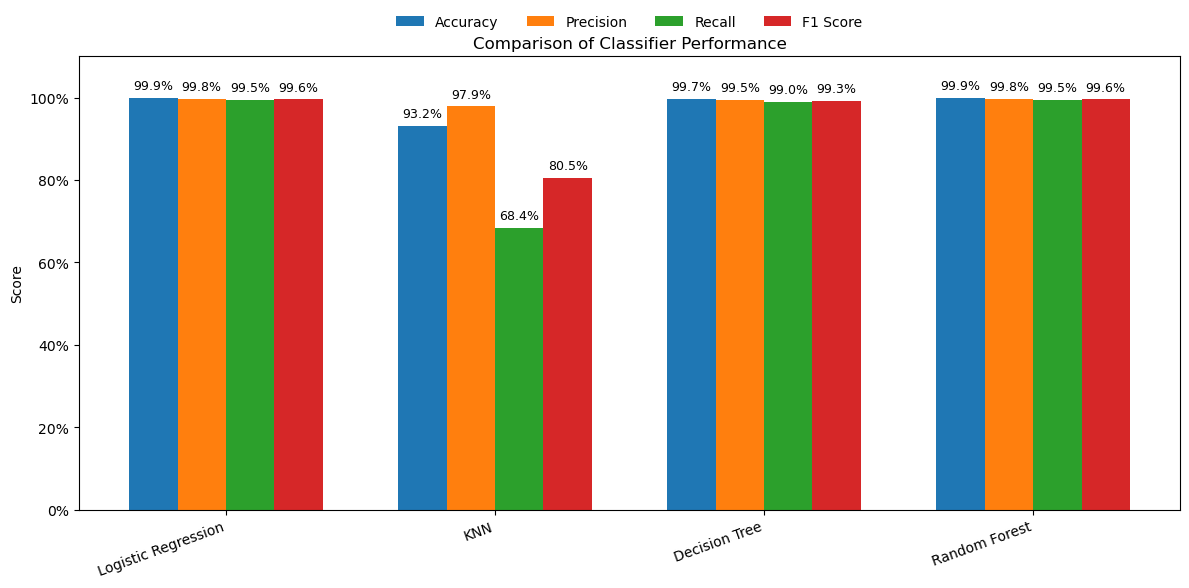

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Hard-coded values of all models
model_names       = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']
accuracy_scores   = [0.999, 0.932, 0.997, 0.999]
precision_scores  = [0.998, 0.979, 0.995, 0.998]
recall_scores     = [0.995, 0.684, 0.990, 0.995]
f1_scores         = [0.996, 0.805, 0.993, 0.996]

n_models = len(model_names)
inds     = np.arange(n_models)
width    = 0.18

fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(inds             , accuracy_scores,  width, label='Accuracy')
bars2 = ax.bar(inds + width     , precision_scores, width, label='Precision')
bars3 = ax.bar(inds + 2*width   , recall_scores   , width, label='Recall')
bars4 = ax.bar(inds + 3*width   , f1_scores       , width, label='F1 Score')

# Annotate each bar with a percentage, one decimal place
for bar_group in (bars1, bars2, bars3, bars4):
    for bar in bar_group:
        h = bar.get_height()
        ax.annotate(f'{h*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4),               # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

# Formating Y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_ylim(0, 1.10)  # give extra headroom

# Moving legend to top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

# Ticks and labels
ax.set_xticks(inds + 1.5*width)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Comparison of Classifier Performance')

plt.tight_layout()
plt.show()


Here we can clearly see Logistic Regression and Random Forest sit at the top with 99.9% accuracy, 99.8% Precision, 99.5% Recall and 99.6% F1 Score. Which means both models are almost clearly identifying churners and non-churners. To further decide on which one performs the best, I am going to check with ROC curves

## b) Receiver Operating Charecteristic Curve (ROC curve)

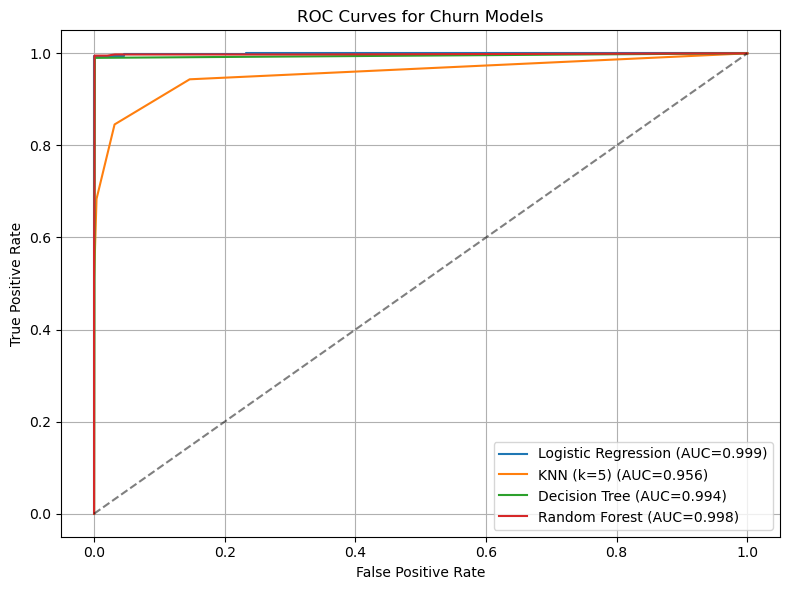

In [93]:
# Overlaying all models’ ROC curves gives a clear, threshold-independent comparison.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))
for name, y_proba in [
    ("Logistic Regression", y_proba_lr),
    ("KNN (k=5)",            y_proba_knn),
    ("Decision Tree",        y_proba_dt),
    ("Random Forest",        y_proba_rf)
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], 'k--', alpha=0.5)  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Churn Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


## 4.1. Rationale for Model Choices, Pros and Cons

### 1. Logistic Regression
   
- Why Use it - As our interpretable baseline, logistic regression assigns explicit "weights" to each predictor, allowing us to directly answer Purpose #2 (Discover Key Churn Drivers) by quantifying how balance, tenure, complaint history, and other factors influence churn probability.
  
- Problem alignment - It determines whether a basic linear combination of our customer indicators can already distinguish churners from non-churners.

- Pros - Trains and predicts quickly, coefficients are instantly interpretable and requires minimal preparation beyond scaling.

- Cons - Assumes a linear decision boundary and non-linear interactions require manual feature engineering.

### 2. K-Nearest Neighbour (KNN)
   
- Why Use it - A non-parametric method for identifying local clusters of similar customers, fulfilling Purpose #3 (Compare Modeling Approaches) by determining whether "neighborhood" effects outperform a global linear model.
  
- Problem alignment - It can identify tiny local trends in data clusters of high-risk churners that linear algorithms may overlook.

- Pros - Conceptually easy to understand; may capture complex borders without feature changes.

- Cons - The prediction cost increases with data quantity and is extremely sensitive to feature scaling and k choice. At k = 5, the model obtained great precision (97.9%) but low recall (68.4%), missing approximately 31.6% of churners.

### 3. Decision Tree
   
- Why Use it - Decision trees create "if-then" rules that serve Purpose #4 (Translate Insights into Action) by identifying high-risk segments (e.g., "Complaint > 0 → churn").
  
- Problem alignment - Trees detect non-linear interactions, for example, low PointsEarned mixed with high balance implies churn risk—without the need for human feature transformations.  They also reveal the most significant separation points.

- Pros - Handles non-linear interactions automatically; requires minimal preprocessing; and produces thresholds that can be used to inform targeted retention strategies.

- Cons - Single trees are prone to overfitting—the perfect train/test accuracy (1.000) masks a modest decline in test AUC (0.994), and little data changes can significantly alter the tree structure.

### 4. Random Forest
   
- Why Use it - Our randomized tree ensemble achieves best-in-class performance for Purpose #1 (Building a Churn-Prediction Model) by minimizing overfitting and capturing complicated relationships.
  
- Problem alignment - It is robust, high-accuracy churn prediction and a measure of feature relevance to identify significant churn drivers.

- Pros - Achieves 99.9% accuracy, 99.8% precision, and 99.5% recall on churners, with an AUC of 0.998; resilient to noisy features; and gives trustworthy feature-importance rankings.

- Cons - Less interpretable than a single tree; training (100 estimators) and serialization take longer; significance scores may be skewed towards high-cardinality features.

# 5. Discussion, Key Insights & Conclusion

## 5.1 Discussion of Visualized Results

- **Churn Balance & Distributions**

The countplot and pie chart showed a considerable class imbalance (about 80% retention vs. 20% turnover), highlighting the importance of maintaining stratification in train/test divides.  The histograms of our five standardized numeric characteristics displayed different shapes: age is broadly bell-shaped, balance is bimodal (several zero-balance accounts plus a cluster of high balances), estimated salary and points earned are reasonably consistent, and credit score is approximately normal.  These plots validated the need for scaling and indicated that our models must handle skewed, bimodal, and uniform distributions.

- **Discrete Feature Rates**

Complain - Nearly 100% churn rate complaint history is by far the most powerful churn predictor.

IsActiveMember - Only about 20% of active members churn, demonstrating the protective effect of involvement.

HasCrCard & Gender_Male - Both have lower churn (approximately 20-25%), although far lower than complain.

Geography - Customers churn at approx 25% in Spain, approx 30% in Germany, and approx 20% in France, demonstrating minimal regional variance.

- **Correlation Analyses**

The bar chart of |Pearson r| with churn ranked "Complain" as approx 1.0, followed by Age (approx 0.25), IsActiveMember (approx0.15), and Balance (approx 0.12).  All other numerical features correlated poorly (|r| < 0.05).  The entire heatmap demonstrated that no two predictors are substantially collinear, which simplifies feature selection and model interpretation.

## 5.2 Discovered Knowledge

1. Churn risk is primarily determined by the history of complains.  Customers who have filed a complaint almost usually leave.
2. Engagement is protective.  Active members have considerably lower churn.
3. Balance and tenure are less important extremely low or very high balances, as well as short vs lengthy tenures, have a minor influence on turnover.
4. Demographics and geography provide tiny but relevant nuance, younger consumers churn slightly more, and regional loyalty differs (France has the lowest turnover, Germany has the most).

## 5.3 Conclusion

Our exploratory research reveals "Complain" as the single most important churn cause, with membership status, balance extremes, and age as secondary contributors.  Random Forest and Logistic Regression yield near-perfect detection approx 99.9% accuracy, AUC = 0.998-0.999 and F1 approx 0.998. Decision Tree trails and KNN underperforms on minority churn recall.

I recommend deploying Random Forest as our primary production model due to its exceptional ability to detect churn with high sensitivity and its robustness across varied customer profiles, while simultaneously running Logistic Regression in parallel as an interpretable dashboard that provides clear coefficient‐driven insights and enables rapid “what-if” scenario testing.
